In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [3]:
master_products = pd.read_csv("../data/phase1/master_products.csv")

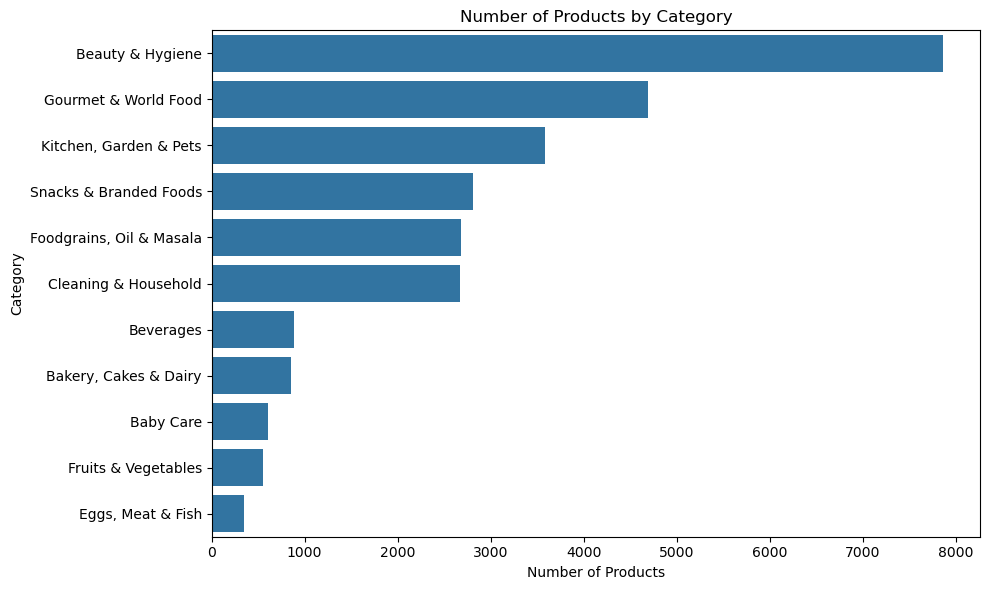

In [4]:
category_counts = master_products["category"].value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(
    x=category_counts.values,
    y=category_counts.index
)
plt.title("Number of Products by Category")
plt.xlabel("Number of Products")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

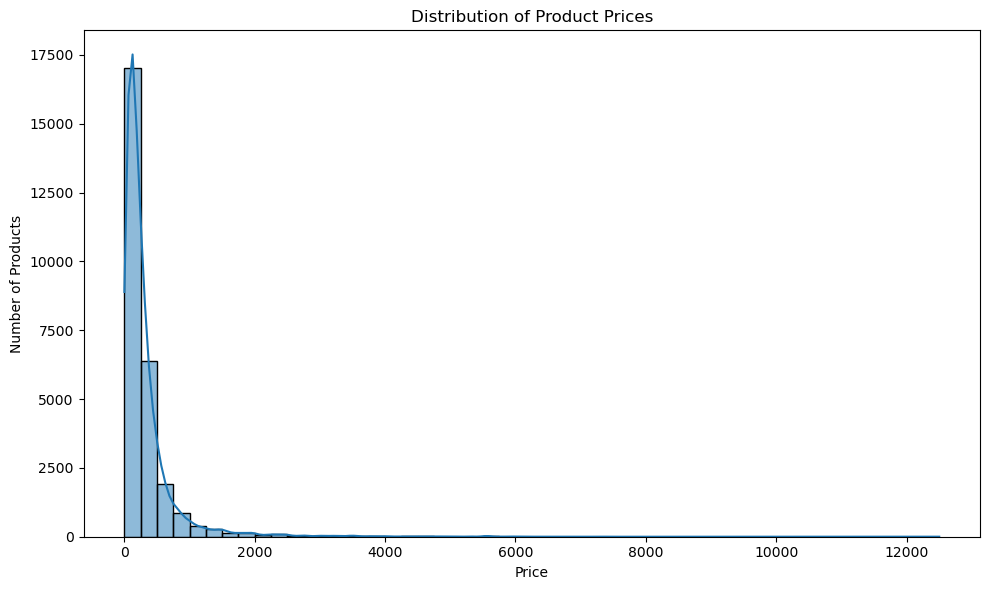

In [5]:
plt.figure(figsize=(10,6))
sns.histplot(
    master_products["price"],
    bins=50,
    kde=True
)
plt.title("Distribution of Product Prices")
plt.xlabel("Price")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.show()

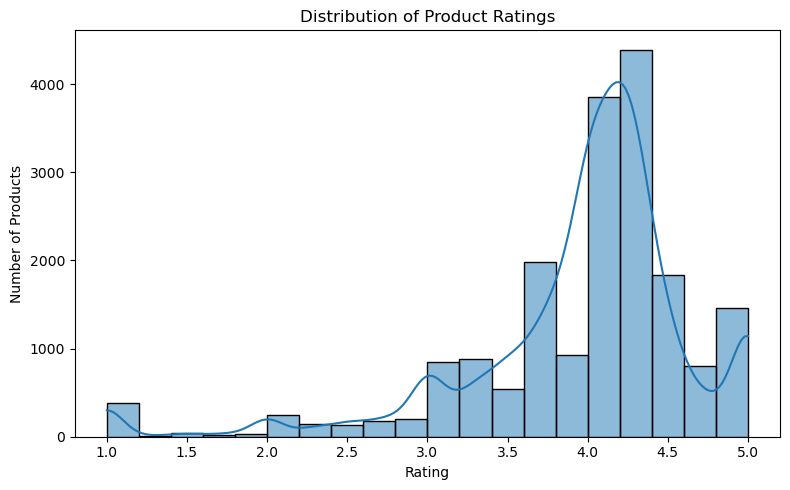

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(
    master_products["rating"].dropna(),
    bins=20,
    kde=True
)
plt.title("Distribution of Product Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.show()

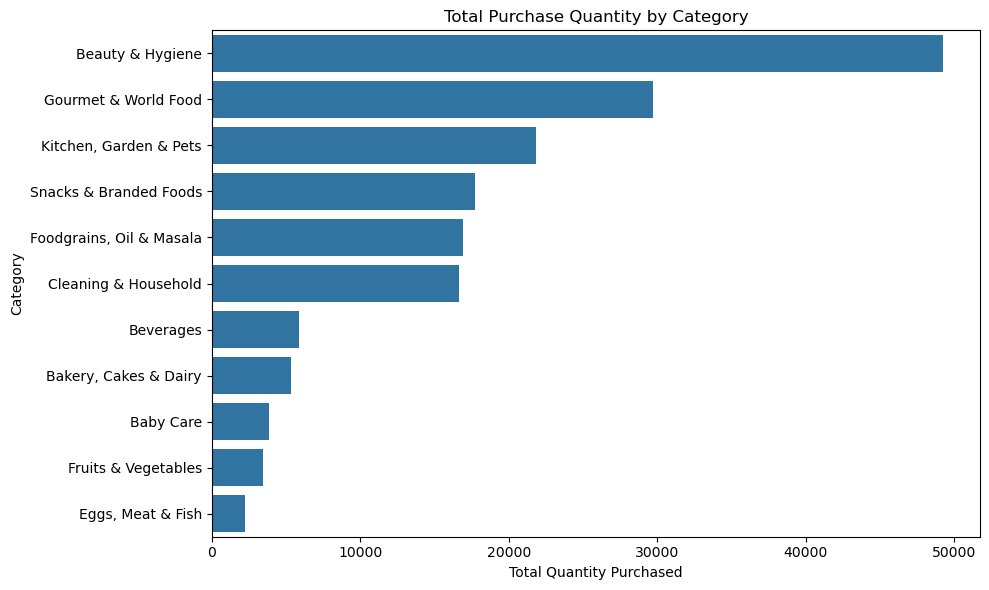

In [7]:
transactions = pd.read_csv("../data/phase1/transactions.csv")
category_purchase = (
    transactions
    .merge(
        master_products[["product_id", "category"]],
        on="product_id",
        how="left"
    )
    .groupby("category")["quantity"]
    .sum()
    .sort_values(ascending=False)
)
plt.figure(figsize=(10,6))
sns.barplot(
    x=category_purchase.values,
    y=category_purchase.index
)
plt.title("Total Purchase Quantity by Category")
plt.xlabel("Total Quantity Purchased")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

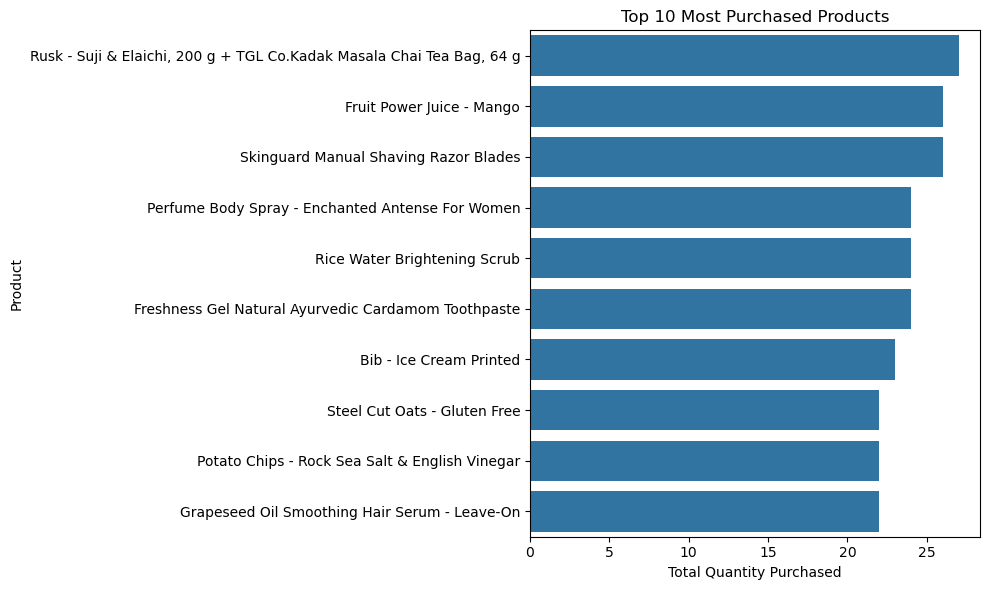

In [8]:
top_products = (
    transactions.groupby("product_id")["quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
    .merge(
        master_products[["product_id", "product_name"]],
        on="product_id",
        how="left"
    )
)
plt.figure(figsize=(10,6))
sns.barplot(
    data=top_products,
    x="quantity",
    y="product_name"
)
plt.title("Top 10 Most Purchased Products")
plt.xlabel("Total Quantity Purchased")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

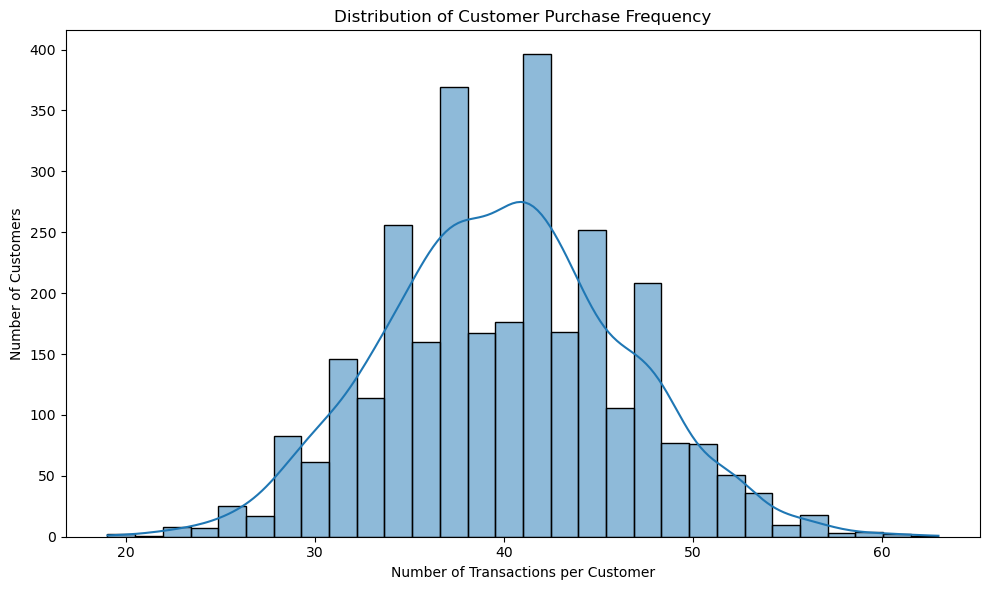

In [9]:
customer_purchase_counts = (
    transactions
    .groupby("customer_id")["transaction_id"].count()
)
plt.figure(figsize=(10,6))
sns.histplot(
    customer_purchase_counts,
    bins=30,
    kde=True
)
plt.title("Distribution of Customer Purchase Frequency")
plt.xlabel("Number of Transactions per Customer")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

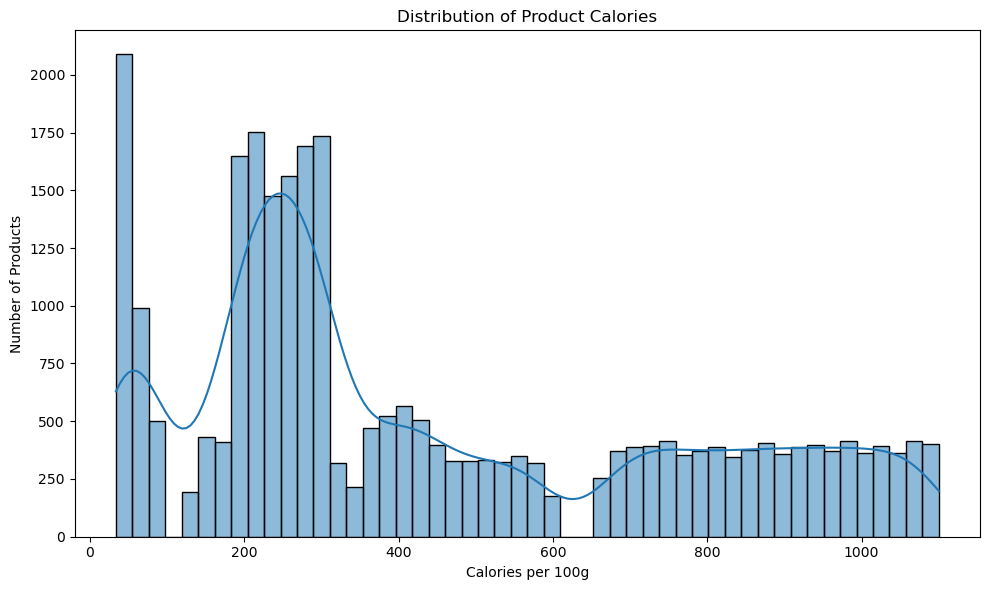

In [12]:
plt.figure(figsize=(10,6))
sns.histplot(
    master_products["calories_kcal"].dropna(),
    bins=50,
    kde=True
)
plt.title("Distribution of Product Calories")
plt.xlabel("Calories per 100g")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.show()

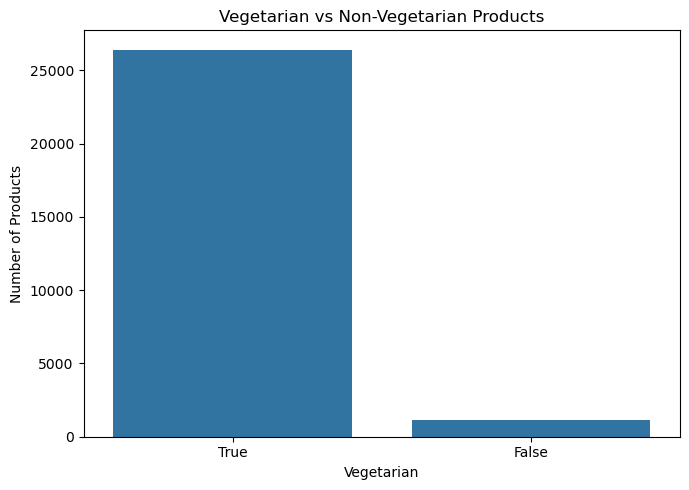

In [13]:
vegetarian_counts = master_products["vegetarian"].value_counts()
plt.figure(figsize=(7,5))
sns.barplot(
    x=vegetarian_counts.index.astype(str),
    y=vegetarian_counts.values
)
plt.title("Vegetarian vs Non-Vegetarian Products")
plt.xlabel("Vegetarian")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.show()

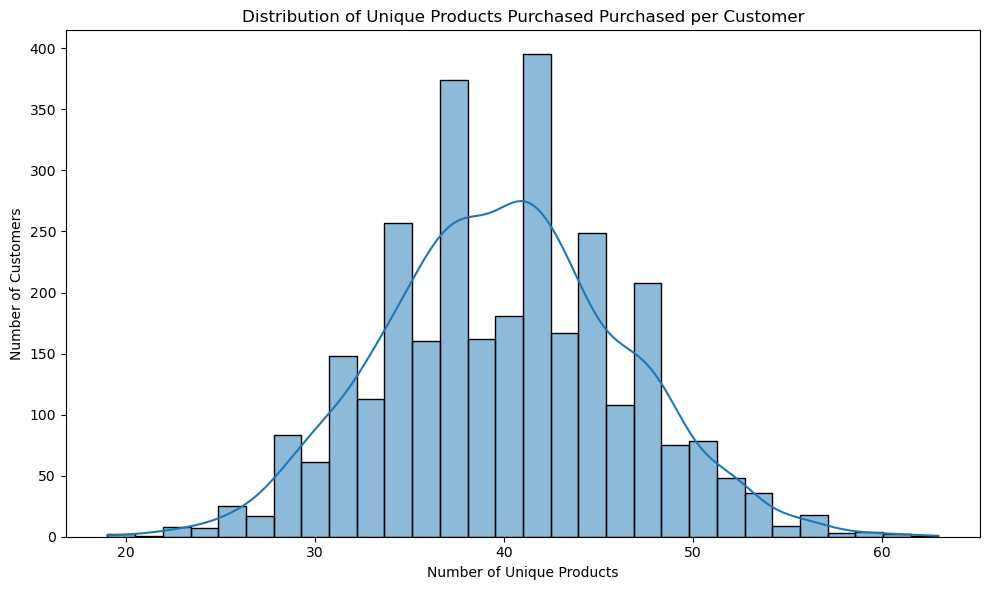

In [14]:
customer_unique_products = (
    transactions
    .groupby("customer_id")["product_id"].nunique()
)
plt.figure(figsize=(10,6))
sns.histplot(
    customer_unique_products,
    bins=30,
    kde=True
)
plt.title("Distribution of Unique Products Purchased Purchased per Customer")
plt.xlabel("Number of Unique Products")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

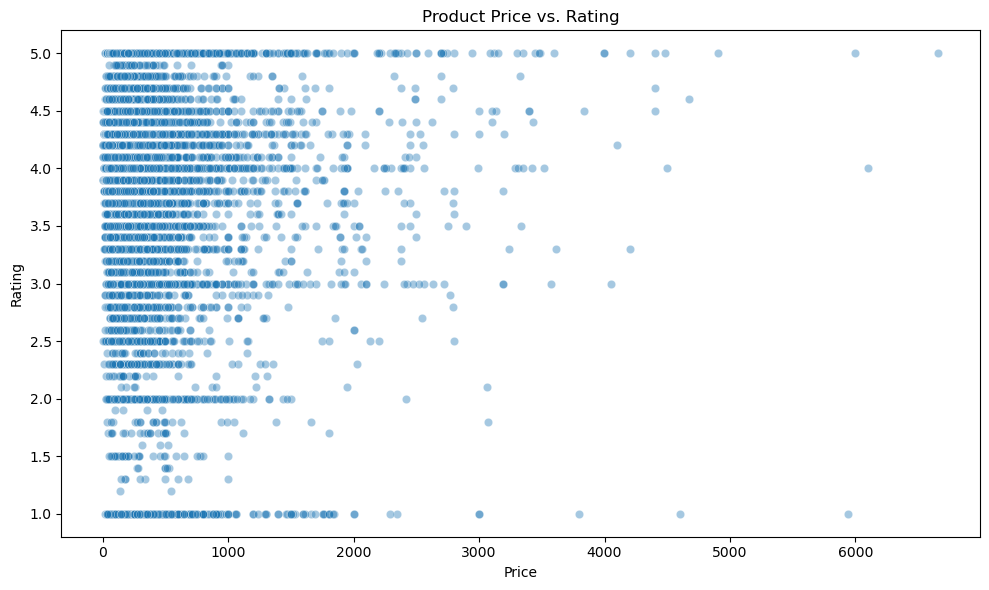

In [16]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=master_products,
    x="price",
    y="rating",
    alpha=0.4
)
plt.title("Product Price vs. Rating")
plt.xlabel("Price")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()

C:\Users\Nilabha\AppData\Local\Temp\ipykernel_5724\4006171372.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  transactions["purchase_date"] = pd.to_datetime(transactions["purchase_date"])
C:\Users\Nilabha\AppData\Local\Temp\ipykernel_5724\4006171372.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["quantity"]


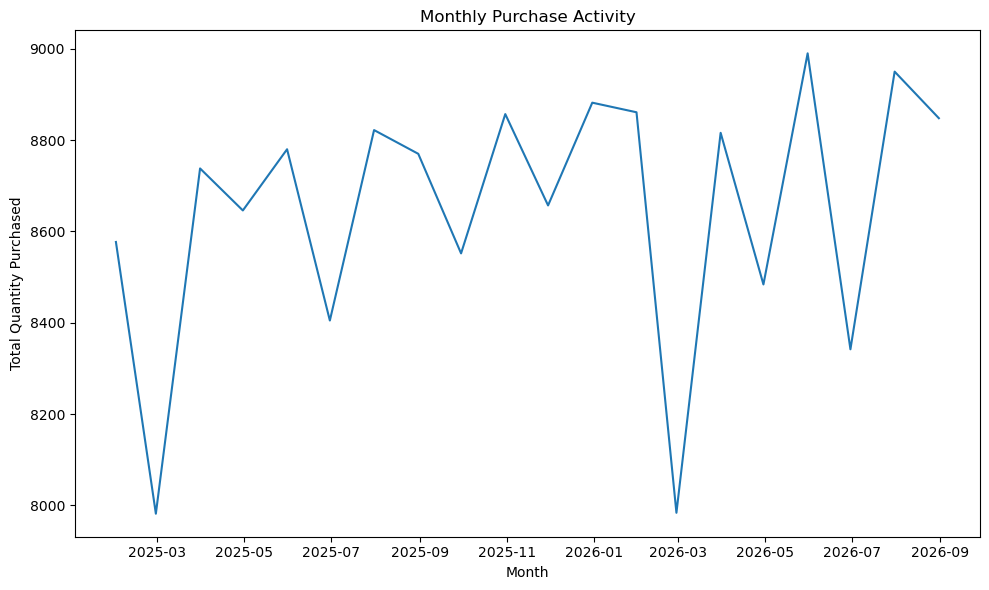

In [17]:
transactions["purchase_date"] = pd.to_datetime(transactions["purchase_date"])
monthly_purchases = (
    transactions
    .set_index("purchase_date")
    .resample("M")["quantity"]
    .sum()
)
plt.figure(figsize=(10,6))
sns.lineplot(
    x=monthly_purchases.index,
    y=monthly_purchases.values
)
plt.title("Monthly Purchase Activity")
plt.xlabel("Month")
plt.ylabel("Total Quantity Purchased")
plt.tight_layout()
plt.show()